# Detecting DeepFakes

## Importing labraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
from tqdm.auto import tqdm # Progress bar
import matplotlib as plt
import matplotlib.pyplot as plt  


## Set GPU 'cuda' 

In [2]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Preprocessing

In [3]:
# Define Img Transformation for classification purpose only 
# We use standard ImageNet normalization and resize images to 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Load data

In [4]:
# Path to dataset
data_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'

# Load folders using ImageFolder (it automatically labels images based on folder names)
train_ds = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
valid_ds = datasets.ImageFolder(os.path.join(data_dir, 'valid'), transform=transform)

# DataLoaders handle shuffling and batching images for the GPU
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True) # no need to shuffel Validation data

print(f"Training images: {len(train_ds)} | Validation images: {len(valid_ds)}")

# Get Class Information
class_names = train_ds.classes
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

Training images: 100000 | Validation images: 20000
Detected 2 classes: ['fake', 'real']


## Model Architecture 
We use **Transfer Learning**. Instead of building a model from scratch, we use **ResNet-18**, which already "knows" how to recognize shapes and textures. We simply replace the final layer to output a "Real" or "Fake" prediction.

In [5]:
# Load a pre-trained ResNet18 model
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers so we don't destroy the pre-trained weights during initial training
for param in model.parameters():
    param.requires_grad = False

# Replace the 'fc' (Fully Connected) layer
# ResNet18's original layer has 512 input features and 1000 output classes
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0.4),       # Dropout helps prevent overfitting
    nn.Linear(256, 2),     # Output layer: 2 classes (Real vs Fake)
    nn.LogSoftmax(dim=1)   # Better for numerical stability
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s] 


## Training Loop with Scoring and Validation
This loop tracks both Training and Validation scores to help you identify if the model is overfitting.

In [6]:
from tqdm.auto import tqdm # Import progress bar

# 1. Setup Loss and Optimizer
criterion = nn.NLLLoss() 
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# 2. History dictionary
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

def run_epoch(epoch, epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct = 0.0, 0
    
    # Wrap train_loader with tqdm for a live progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]", unit="batch")
    
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Stats update
        batch_loss = loss.item()
        train_loss += batch_loss * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        
        # Update the progress bar text with current batch loss
        train_pbar.set_postfix(loss=f"{batch_loss:.4f}")

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct = 0.0, 0
    
    # Wrap valid_loader with tqdm
    val_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [VALID]", unit="batch")
    
    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)

    # 3. Calculate Final Epoch Metrics
    t_loss = train_loss / len(train_ds)
    v_loss = val_loss / len(valid_ds)
    t_acc = train_correct.double() / len(train_ds)
    v_acc = val_correct.double() / len(valid_ds)
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc.cpu().item())
    history['val_acc'].append(v_acc.cpu().item())
    
    # Final print for the epoch
    print(f"\nFINISH Epoch {epoch+1} -> Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | Val Loss: {v_loss:.4f}\n")

# 4. Main Execution Loop
print("Starting Training...")
for e in range(3):
    run_epoch(e, 3)

Starting Training...


Epoch 1/3 [TRAIN]:   0%|          | 0/782 [00:00<?, ?batch/s]

Epoch 1/3 [VALID]:   0%|          | 0/157 [00:00<?, ?batch/s]


FINISH Epoch 1 -> Train Acc: 0.7755 | Val Acc: 0.8135 | Val Loss: 0.4095



Epoch 2/3 [TRAIN]:   0%|          | 0/782 [00:00<?, ?batch/s]

Epoch 2/3 [VALID]:   0%|          | 0/157 [00:00<?, ?batch/s]


FINISH Epoch 2 -> Train Acc: 0.8123 | Val Acc: 0.8226 | Val Loss: 0.3905



Epoch 3/3 [TRAIN]:   0%|          | 0/782 [00:00<?, ?batch/s]

Epoch 3/3 [VALID]:   0%|          | 0/157 [00:00<?, ?batch/s]


FINISH Epoch 3 -> Train Acc: 0.8249 | Val Acc: 0.8357 | Val Loss: 0.3692



## Validation Graph and Predictions
After training, we visualize the results and test the model on a single image.

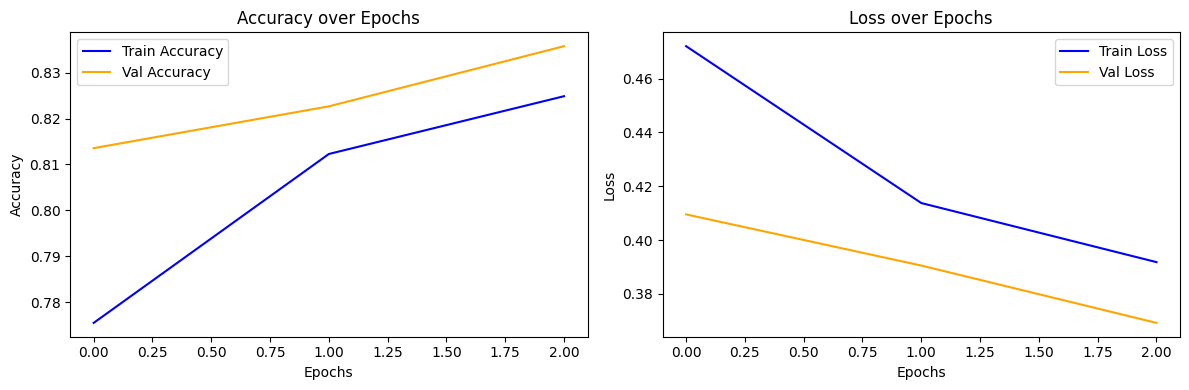

In [7]:

# --- PLOT GRAPH ---
plt.figure(figsize=(12, 4))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(history['val_acc'], label='Val Accuracy', color='orange')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # Prevents labels from overlapping
plt.show()


## Predection Function

Prediction: fake (99.83% confidence)


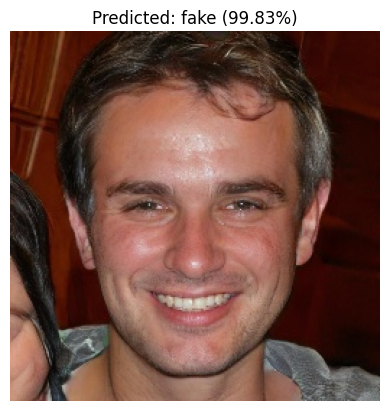

Prediction: real (80.99% confidence)


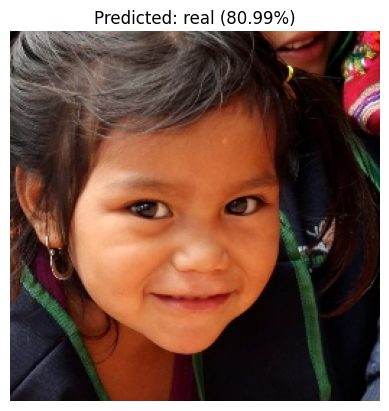

In [8]:

def predict_image(image_path):
    from PIL import Image
    import torch.nn.functional as F
    
    # 1. Prepare Model
    model.eval()
    
    # 2. Load and Preprocess Image
    img = Image.open(image_path).convert('RGB') # Ensure 3 channels
    img_t = transform(img).unsqueeze(0).to(device) # Add batch dimension & move to GPU
    
    # 3. Inference
    with torch.no_grad():
        output = model(img_t)
        
        # Convert output to probabilities using Softmax
        probs = F.softmax(output, dim=1)
        conf, predicted = torch.max(probs, 1)
        
    # 4. Display Results
    label = class_names[predicted.item()]
    confidence = conf.item() * 100
    
    print(f"Prediction: {label} ({confidence:.2f}% confidence)")
    
    # Show the image
    plt.imshow(img)
    plt.title(f"Predicted: {label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show() # <--- CRITICAL: This forces the image to display

# --- HOW TO FIND A PATH ON KAGGLE ---
# Since you have the dataset from your image, try this path:
test_image_path0 = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake/008BYSE725.jpg'
test_image_path1 = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/real/00007.jpg'
# Run the prediction
predict_image(test_image_path0) # This is a fake image check whats the prdection
predict_image(test_image_path1) # This is a real image check whats the prdection

## Save Model

In [9]:
# Define the file name (must end in .pth or .pt)
model_path = 'deepfake_detector_resnet18.pth'

# Save the model weights
torch.save(model.state_dict(), model_path)

print(f"Model saved successfully to {model_path}")

Model saved successfully to deepfake_detector_resnet18.pth
